<a href="https://colab.research.google.com/github/Chalhotra/ViT-Token-Economy/blob/priyanshu%2Fprogressive-testing/notebooks/05_tome_testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ToMe (Token Merging) Testing & Visualization (ImageNet-100)

This notebook tests the ToMe (Token Merging via Bipartite Soft Matching) functionality and provides visualizations of:
- Which patches are merged at each reduction layer
- Token merging behavior (pairs of similar tokens are merged using weighted averaging)
- Token reduction statistics through the network
- Performance vs. accuracy trade-offs
- Comparison between ToMe and baseline models

**ToMe Strategy**: Unlike TopK (discards) or EViT (fuses into 1 token), ToMe identifies similar token pairs using bipartite matching and merges them with weighted averaging, preserving information while reducing sequence length.

In [1]:
# GitHub token-based setup removed.
# If running in a fresh Colab runtime, uncomment these lines:
!git clone https://github.com/Chalhotra/ViT-Token-Economy.git
%cd ViT-Token-Economy

Cloning into 'ViT-Token-Economy'...
remote: Enumerating objects: 332, done.
remote: Counting objects: 100% (111/111), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 332 (delta 63), reused 76 (delta 46), pack-reused 221 (from 1)
Receiving objects: 100% (332/332), 656.42 KiB | 14.59 MiB/s, done.
Resolving deltas: 100% (186/186), done.
/content/ViT-Token-Economy


In [2]:
!git checkout tome_testing

Branch 'tome_testing' set up to track remote branch 'tome_testing' from 'origin'.
Switched to a new branch 'tome_testing'


In [3]:
!pip -q install -r requirements.txt
!pip -q install -e .

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for vit-deit-baselines (pyproject.toml) ... done


In [4]:
# Import core modules
from src.imagenet_mapping import build_imagenet100_to_1k_map
from src.models import ModelConfig, create_model, shrink_imagenet1k_head_to_imagenet100
from src.data import DataConfig, load_imagenet100_split, build_transform_for_model, apply_timm_preprocess, build_loader
from src.eval import evaluate_accuracy_latency_throughput, compute_gflops
from src.utils import get_device, num_params
from src.test_models.tome import ToMeConfig, apply_tome_merging, BlockToMeAdapter, collect_tome_viz
import torch
import torch.nn as nn

# Import visualization libraries
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import seaborn as sns
from typing import List, Tuple, Dict
import pandas as pd

# Set matplotlib style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [5]:
device = get_device()
maps = build_imagenet100_to_1k_map()
print(f"Using device: {device}")

Using device: cuda


## Utility Functions for ToMe Visualization

In [6]:
def extract_tome_merge_info(model, x):
    """
    Extract token merging information from ToMe blocks.
    Returns list of (layer_idx, cluster_assignments) and token counts.
    """
    merge_info = []
    token_counts = []

    # Get initial token count
    B, N, C = x.shape
    num_special = 2 if hasattr(model, 'dist_token') and model.dist_token is not None else 1
    token_counts.append(N - num_special)  # exclude special tokens

    # Initialize attn_size for proportional attention
    attn_size = None
    if hasattr(model, '_tome_prop_attn') and model._tome_prop_attn:
        attn_size = torch.ones(B, N, 1, device=x.device, dtype=x.dtype)

    # Forward through blocks and collect merge info
    for i, block in enumerate(model.blocks):
        with torch.no_grad():
            if isinstance(block, BlockToMeAdapter):
                x, attn_size, cluster_idx = block(x, attn_size=attn_size)
                if cluster_idx is not None:
                    merge_info.append((i, cluster_idx.cpu()))
                    token_counts.append(x.shape[1] - num_special)
                else:
                    token_counts.append(token_counts[-1])
            else:
                x = block(x)
                token_counts.append(token_counts[-1])

    return merge_info, token_counts


def visualize_tome_merging(image, patch_size, merge_info, token_counts, model_name):
    """
    Visualize token merging patterns in ToMe.
    Shows patches colored by their cluster assignment (which tokens were merged together).

    Args:
        image: Original PIL image or tensor
        patch_size: Size of patches (e.g., 16)
        merge_info: List of (layer_idx, cluster_assignments_tensor)
        token_counts: List of token counts at each layer
        model_name: Name for the plot title
    """
    # Convert image to numpy if needed
    if isinstance(image, torch.Tensor):
        img_np = image.permute(1, 2, 0).cpu().numpy()
    else:
        img_np = np.array(image)

    # Normalize if needed
    if img_np.max() > 1.0:
        img_np = img_np / 255.0

    h, w = img_np.shape[:2]
    n_patches_h = h // patch_size
    n_patches_w = w // patch_size
    total_patches = n_patches_h * n_patches_w

    # Create visualization
    n_merge_layers = len(merge_info)
    fig, axes = plt.subplots(1, n_merge_layers + 1, figsize=(5 * (n_merge_layers + 1), 5))
    if n_merge_layers == 0:
        axes = [axes]

    # Show original image
    axes[0].imshow(img_np)
    axes[0].set_title(f'Original Image\n{total_patches} patches')
    axes[0].axis('off')

    # Show merged versions
    for idx, (layer_idx, cluster_assignments) in enumerate(merge_info):
        ax = axes[idx + 1]

        # Cluster assignments: [B, N_merged]
        clusters_np = cluster_assignments[0].numpy()  # Take first batch item

        # Create a colored overlay based on cluster assignments
        # Use a colormap to show which patches belong to the same merged token
        unique_clusters = np.unique(clusters_np)
        n_clusters = len(unique_clusters)

        # Create colormap
        cmap = plt.cm.get_cmap('tab20' if n_clusters <= 20 else 'hsv')

        # Create overlay
        overlay = img_np.copy()

        # Map each remaining token to a color
        for cluster_id, cluster_val in enumerate(clusters_np):
            color = cmap(cluster_id / max(1, n_clusters - 1))[:3]

            # Find original patch index (clusters_np contains original patch indices)
            patch_idx = int(cluster_val)
            if 0 <= patch_idx < total_patches:
                pi = patch_idx % n_patches_h
                pj = patch_idx // n_patches_h

                if pi < n_patches_h and pj < n_patches_w:
                    y_start, y_end = pi * patch_size, (pi + 1) * patch_size
                    x_start, x_end = pj * patch_size, (pj + 1) * patch_size

                    # Add colored border
                    border_width = 2
                    overlay[y_start:y_start+border_width, x_start:x_end] = color
                    overlay[y_end-border_width:y_end, x_start:x_end] = color
                    overlay[y_start:y_end, x_start:x_start+border_width] = color
                    overlay[y_start:y_end, x_end-border_width:x_end] = color

        remaining_tokens = len(clusters_np)
        merged_count = total_patches - remaining_tokens
        reduction_rate = remaining_tokens / total_patches

        ax.imshow(overlay)
        ax.set_title(
            f'After Layer {layer_idx}\n'
            f'{remaining_tokens}/{total_patches} tokens ({reduction_rate:.1%})\n'
            f'Merged: {merged_count} pairs'
        )
        ax.axis('off')

    plt.suptitle(f'{model_name} - ToMe Token Merging Visualization', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


def plot_tome_token_timeline(token_counts, reduction_locs, model_name):
    """
    Plot how token count changes through layers with ToMe merging.
    Note: ToMe reduces by r tokens per merging layer (merges r pairs).
    """
    layers = list(range(len(token_counts)))

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(layers, token_counts, marker='o', linewidth=2, markersize=8, label='Patch tokens', color='steelblue')

    # Highlight reduction locations
    for loc in reduction_locs:
        if loc < len(token_counts):
            ax.axvline(x=loc, color='red', linestyle='--', alpha=0.5)
            ax.text(loc, max(token_counts) * 0.95, f'Merge at {loc}',
                   rotation=90, verticalalignment='top', fontsize=9)

    ax.set_xlabel('Layer Index', fontsize=12)
    ax.set_ylabel('Number of Patch Tokens', fontsize=12)
    ax.set_title(f'{model_name} - Token Count Through Layers (ToMe)', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.legend()

    # Add percentage annotations
    initial = token_counts[0]
    for i, count in enumerate(token_counts):
        if i in reduction_locs or i == 0 or i == len(token_counts) - 1:
            pct = count / initial * 100
            ax.annotate(f'{count} ({pct:.1f}%)',
                       xy=(i, count),
                       xytext=(0, 10),
                       textcoords='offset points',
                       ha='center',
                       fontsize=9,
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.5))

    plt.tight_layout()
    plt.show()


def compare_tome_configurations(results_list: List[Dict], title: str = "ToMe Configuration Comparison"):
    """
    Create comparison plots for different ToMe configurations.

    Args:
        results_list: List of result dicts with keys: config_name, accuracy, gflops, params_m, latency, throughput
    """
    df = pd.DataFrame(results_list)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Accuracy comparison
    axes[0, 0].bar(range(len(df)), df['acc1'], color='steelblue')
    axes[0, 0].set_xticks(range(len(df)))
    axes[0, 0].set_xticklabels(df['config_name'], rotation=45, ha='right')
    axes[0, 0].set_ylabel('Top-1 Accuracy (%)')
    axes[0, 0].set_title('Accuracy Comparison')
    axes[0, 0].grid(True, alpha=0.3)

    # GFLOPs comparison
    axes[0, 1].bar(range(len(df)), df['gflops'], color='coral')
    axes[0, 1].set_xticks(range(len(df)))
    axes[0, 1].set_xticklabels(df['config_name'], rotation=45, ha='right')
    axes[0, 1].set_ylabel('GFLOPs')
    axes[0, 1].set_title('Computational Cost')
    axes[0, 1].grid(True, alpha=0.3)

    # Latency comparison
    axes[1, 0].bar(range(len(df)), df['latency_ms'], color='mediumseagreen')
    axes[1, 0].set_xticks(range(len(df)))
    axes[1, 0].set_xticklabels(df['config_name'], rotation=45, ha='right')
    axes[1, 0].set_ylabel('Latency (ms)')
    axes[1, 0].set_title('Inference Latency')
    axes[1, 0].grid(True, alpha=0.3)

    # Efficiency plot (Accuracy vs GFLOPs)
    axes[1, 1].scatter(df['gflops'], df['acc1'], s=100, alpha=0.6, c=range(len(df)), cmap='viridis')
    for i, row in df.iterrows():
        axes[1, 1].annotate(row['config_name'],
                           (row['gflops'], row['acc1']),
                           xytext=(5, 5),
                           textcoords='offset points',
                           fontsize=8)
    axes[1, 1].set_xlabel('GFLOPs')
    axes[1, 1].set_ylabel('Top-1 Accuracy (%)')
    axes[1, 1].set_title('Efficiency Plot')
    axes[1, 1].grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

    # Print summary table
    print("\n" + "="*80)
    print(f"{title} - Summary Table")
    print("="*80)
    print(df.to_string(index=False))
    print("="*80 + "\n")

## Test ToMe with Different Configurations

In [7]:
def run_tome_test(
    model_id: str,
    tome_config: ToMeConfig,
    config_name: str,
    batch_size: int = 64,
    visualize: bool = True
):
    """
    Run model with specific ToMe configuration and optionally visualize.
    """
    print(f"\n{'='*80}")
    print(f"Testing: {config_name}")
    print(f"Model: {model_id}")
    print(f"Reduction locations: {tome_config.reduction_loc}")
    print(f"Keep rates: {tome_config.keep_rate}")
    print(f"Proportional attention: {tome_config.prop_attn}")
    print(f"{'='*80}\n")

    # Create model
    model = create_model(ModelConfig(model_id=model_id, pretrained=True))
    model = shrink_imagenet1k_head_to_imagenet100(model, maps.new_to_old_map, num_classes=100)

    # Apply ToMe merging
    model = apply_tome_merging(model, tome_config)
    model = model.to(device).eval()

    # Load data
    ds = load_imagenet100_split(DataConfig(split='validation'))
    transform = build_transform_for_model(model)
    ds_t = apply_timm_preprocess(ds, transform)
    loader = build_loader(ds_t, DataConfig(batch_size=batch_size, split='validation', shuffle=False))

    # Evaluate
    metrics = evaluate_accuracy_latency_throughput(model, loader, device)

    # Compute GFLOPs
    sample = ds_t[0]['pixel_values'].unsqueeze(0).to(device)
    gflops = compute_gflops(model, sample)

    # Visualization
    if visualize and tome_config.enabled:
        # Get a sample image for visualization
        sample_idx = 42  # arbitrary sample
        sample_image = ds[sample_idx]['image']
        sample_tensor = ds_t[sample_idx]['pixel_values'].unsqueeze(0).to(device)

        # Extract merge information
        with torch.no_grad():
            # Embed patches
            x = model.patch_embed(sample_tensor)
            if hasattr(model, 'cls_token'):
                cls_tokens = model.cls_token.expand(sample_tensor.shape[0], -1, -1)
                x = torch.cat((cls_tokens, x), dim=1)
            if hasattr(model, 'pos_embed'):
                x = x + model.pos_embed
            if hasattr(model, 'pos_drop'):
                x = model.pos_drop(x)

            # Extract merge info
            merge_info, token_counts = extract_tome_merge_info(model, x)

        # Visualize token merging
        if merge_info:
            visualize_tome_merging(
                sample_image,
                16,  # patch size
                merge_info,
                token_counts,
                f"{model_id} - {config_name}"
            )

            # Plot token timeline
            plot_tome_token_timeline(
                token_counts,
                list(tome_config.reduction_loc),
                f"{model_id} - {config_name}"
            )

    result = {
        'config_name': config_name,
        'model': model_id,
        'params_m': num_params(model) / 1e6,
        'gflops': gflops,
        **metrics
    }

    print(f"\nResults for {config_name}:")
    print(f"  Top-1 Accuracy: {metrics['acc1']:.2f}%")
    print(f"  GFLOPs: {gflops:.3f}")
    print(f"  Latency: {metrics['latency_ms']:.2f} ms")
    print(f"  Throughput: {metrics['throughput']:.1f} samples/sec")

    return result

## Baseline (No Merging)

In [8]:
# Test baseline without ToMe
baseline_config = ToMeConfig(enabled=False)
baseline_result = run_tome_test(
    model_id='deit_tiny_patch16_224',
    tome_config=baseline_config,
    config_name='Baseline (No Merging)',
    visualize=False
)


Testing: Baseline (No Merging)
Model: deit_tiny_patch16_224
Reduction locations: ()
Keep rates: (1.0,)
Proportional attention: True



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

...

Generating train split:   0%|          | 0/126689 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.3.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.6.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop, blocks.9.attn.attn_drop



Results for Baseline (No Merging):
  Top-1 Accuracy: 88.42%
  GFLOPs: 1.079
  Latency: 1.57 ms
  Throughput: 636.6 samples/sec


## Sanity Check: Keep Rate = 1.0 (Should Match Baseline)

In [9]:
# Sanity check: keep_rate = 1.0 should yield same accuracy
sanity_config = ToMeConfig(
    enabled=True,
    keep_rate=(1.0,),
    reduction_loc=(3, 6, 9),
    exponentiate_single_keep_rate=False,
    prop_attn=True
)
sanity_result = run_tome_test(
    model_id='deit_tiny_patch16_224',
    tome_config=sanity_config,
    config_name='Sanity Check (keep=1.0)',
    visualize=True
)


Testing: Sanity Check (keep=1.0)
Model: deit_tiny_patch16_224
Reduction locations: (3, 6, 9)
Keep rates: (1.0,)
Proportional attention: True



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.3.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.6.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop, blocks.9.attn.attn_drop



Results for Sanity Check (keep=1.0):
  Top-1 Accuracy: 88.42%
  GFLOPs: 1.079
  Latency: 1.11 ms
  Throughput: 901.2 samples/sec



Testing: ToMe keep=[0.25,0.25,0.25]
Model: deit_tiny_patch16_224
Reduction locations: (3, 6, 9)
Keep rates: (0.25, 0.25, 0.25)
Proportional attention: True



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

N=197 cur_patches_before=196 r=147 cur_patches_after=98
N=197 cur_patches_before=196 r=147 cur_patches_after=98
N=197 cur_patches_before=196 r=147 cur_patches_after=98
N=197 cur_patches_before=196 r=147 cur_patches_after=98
N=197 cur_patches_before=196 r=147 cur_patches_after=98
N=197 cur_patches_before=196 r=147 cur_patches_after=98
N=197 cur_patches_before=196 r=147 cur_patches_after=98
N=197 cur_patches_before=196 r=147 cur_patches_after=98
N=197 cur_patches_before=196 r=147 cur_patches_after=98
N=197 cur_patches_before=196 r=147 cur_patches_after=98
N=197 cur_patches_before=196 r=147 cur_patches_after=98
N=197 cur_patches_before=196 r=147 cur_patches_after=98
N=197 cur_patches_before=196 r=147 cur_patches_after=98
N=197 cur_patches_before=196 r=147 cur_patches_after=98
N=197 cur_patches_before=196 r=147 cur_patches_after=98
N=197 cur_patches_before=196 r=147 cur_patches_after=98
N=197 cur_patches_before=196 r=147 cur_patches_after=98
N=197 cur_patches_before=196 r=147 cur_patches_a

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.6.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop, blocks.9.attn.attn_drop


...

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

N=197 cur_patches_before=196 r=20 cur_patches_after=176
N=197 cur_patches_before=196 r=20 cur_patches_after=176
N=197 cur_patches_before=196 r=20 cur_patches_after=176
N=197 cur_patches_before=196 r=20 cur_patches_after=176
N=197 cur_patches_before=196 r=20 cur_patches_after=176
N=197 cur_patches_before=196 r=20 cur_patches_after=176
N=197 cur_patches_before=196 r=20 cur_patches_after=176
N=197 cur_patches_before=196 r=20 cur_patches_after=176
N=197 cur_patches_before=196 r=20 cur_patches_after=176
N=197 cur_patches_before=196 r=20 cur_patches_after=176
N=197 cur_patches_before=196 r=20 cur_patches_after=176
N=197 cur_patches_before=196 r=20 cur_patches_after=176
N=197 cur_patches_before=196 r=20 cur_patches_after=176
N=197 cur_patches_before=196 r=20 cur_patches_after=176
N=197 cur_patches_before=196 r=20 cur_patches_after=176
N=197 cur_patches_before=196 r=20 cur_patches_after=176
N=197 cur_patches_before=196 r=20 cur_patches_after=176
N=197 cur_patches_before=196 r=20 cur_patches_af

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.6.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop, blocks.9.attn.attn_drop


N=197 cur_patches_before=196 r=20 cur_patches_after=176

Results for ToMe keep=[0.90,0.90,0.90]:
  Top-1 Accuracy: 88.72%
  GFLOPs: 1.018
  Latency: 0.98 ms
  Throughput: 1018.4 samples/sec


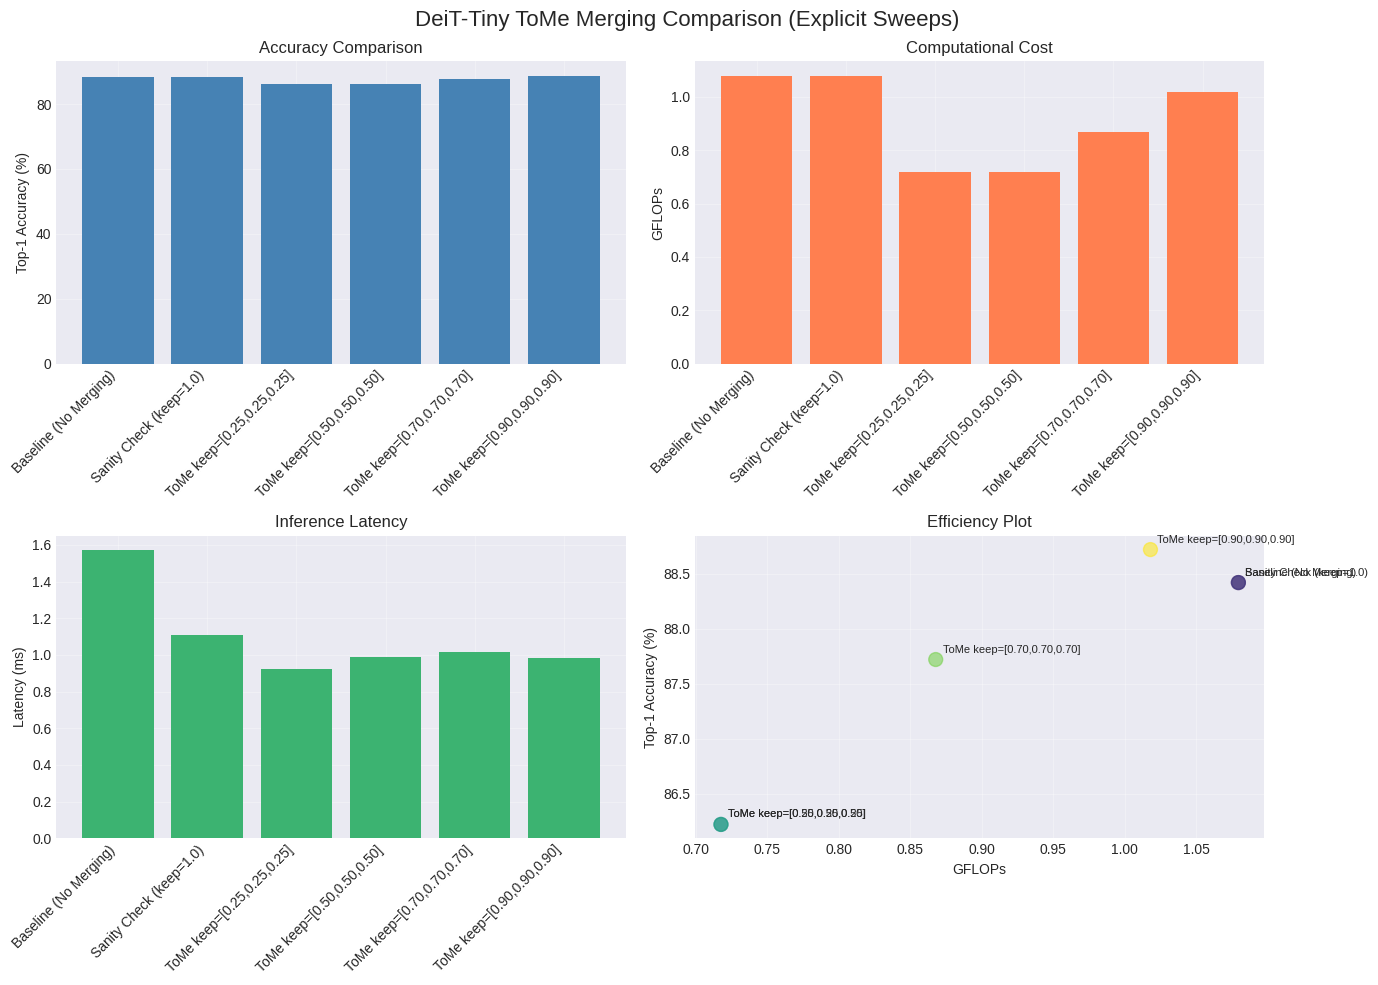


DeiT-Tiny ToMe Merging Comparison (Explicit Sweeps) - Summary Table
               config_name                 model  params_m   gflops  acc1  latency_ms  throughput
     Baseline (No Merging) deit_tiny_patch16_224  5.543716 1.079407 88.42    1.570884  636.584214
   Sanity Check (keep=1.0) deit_tiny_patch16_224  5.543716 1.079407 88.42    1.109604  901.222146
ToMe keep=[0.25,0.25,0.25] deit_tiny_patch16_224  5.543716 0.717519 86.22    0.920223 1086.692608
ToMe keep=[0.50,0.50,0.50] deit_tiny_patch16_224  5.543716 0.717519 86.22    0.990424 1009.668244
ToMe keep=[0.70,0.70,0.70] deit_tiny_patch16_224  5.543716 0.867713 87.72    1.017472  982.827563
ToMe keep=[0.90,0.90,0.90] deit_tiny_patch16_224  5.543716 1.017907 88.72    0.981925 1018.407800



In [10]:
explicit_rates = [0.25, 0.5, 0.7, 0.9]

if 'results' not in globals():
    results = [baseline_result, sanity_result]

for r in explicit_rates:
    cfg = ToMeConfig(
        enabled=True,
        keep_rate=(r, r, r),
        reduction_loc=(3, 6, 9),
        exponentiate_single_keep_rate=False,
        prop_attn=True,
    )
    name = f"ToMe keep=[{r:.2f},{r:.2f},{r:.2f}]"

    if not any(x.get('config_name') == name for x in results):
        out = run_tome_test(
            model_id='deit_tiny_patch16_224',
            tome_config=cfg,
            config_name=name,
            visualize=False,
        )
        results.append(out)

compare_tome_configurations(results, title='DeiT-Tiny ToMe Merging Comparison (Explicit Sweeps)')

In [11]:
# Final combined comparison table for explicit keep-rate sweeps
explicit_names = [
    'ToMe keep=[0.25,0.25,0.25]',
    'ToMe keep=[0.50,0.50,0.50]',
    'ToMe keep=[0.70,0.70,0.70]',
    'ToMe keep=[0.90,0.90,0.90]',
]

df_all = pd.DataFrame(results)
df_explicit = df_all[df_all['config_name'].isin(explicit_names)].copy()

if not df_explicit.empty:
    order = {name: i for i, name in enumerate(explicit_names)}
    df_explicit['order'] = df_explicit['config_name'].map(order)
    df_explicit = df_explicit.sort_values('order').drop(columns=['order'])
    cols = [c for c in ['config_name', 'acc1', 'latency_ms', 'throughput', 'gflops', 'params_m'] if c in df_explicit.columns]
    display(df_explicit[cols].reset_index(drop=True))
else:
    print('No explicit sweep results found yet. Run the explicit sweep cell first.')

,config_name,acc1,latency_ms,throughput,gflops,params_m
0,"ToMe keep=[0.25,0.25,0.25]",86.22,0.920223,1086.692608,0.717519,5.543716
1,"ToMe keep=[0.50,0.50,0.50]",86.22,0.990424,1009.668244,0.717519,5.543716
2,"ToMe keep=[0.70,0.70,0.70]",87.72,1.017472,982.827563,0.867713,5.543716
3,"ToMe keep=[0.90,0.90,0.90]",88.72,0.981925,1018.407800,1.017907,5.543716
